1. Генерация платежной матрицы

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

np.random.seed(42)  
n, m = 18, 17 
A = np.random.randint(-100, 101, size=(n, m))
print("Платёжная матрица A ({}x{}):".format(n, m))
print(A[:5, :5], "...\n")  # выводим фрагмент

Платёжная матрица A (18x17):
[[  2  79  -8 -86   6]
 [ 49 -48 -99 -13  57]
 [ 87 -86  89  89  74]
 [ 31 -12 -41 -87 -92]
 [-20  63 -51   3  31]] ...



2. Реализация алгоритма Брауна Робинсона (фиктивного разыгрывания) для нахождения приближенного решения игры.
5000 = количество итераций

In [14]:
T = 5000  

# Инициализация счётчиков выбранных стратегий
count1 = np.zeros(n, dtype=int)  # для игрока 1 (строки)
count2 = np.zeros(m, dtype=int)  # для игрока 2 (столбцы)

i_curr, j_curr = 0, 0

lower_vals = []
upper_vals = []

for t in range(1, T + 1):
    # Обновляем счётчики на основе выбранных в этом раунде стратегий
    count1[i_curr] += 1
    count2[j_curr] += 1

    # Эмпирические частоты
    p_emp = count1 / t   # вероятности стратегий игрока 1
    q_emp = count2 / t   # вероятности стратегий игрока 2

    # Вычисляем v_lower и v_upper для текущей итерации
    # Ожидаемый выигрыш игрока 1 против каждой чистой стратегии j противника
    payoff_vs_j = np.array([np.sum(p_emp * A[:, j]) for j in range(m)])
    v_lower = np.min(payoff_vs_j)

    # Ожидаемый выигрыш игрока 1 каждой его чистой стратегией против q_emp
    payoff_vs_i = np.array([np.sum(A[i, :] * q_emp) for i in range(n)])
    v_upper = np.max(payoff_vs_i)

    lower_vals.append(v_lower)
    upper_vals.append(v_upper)

    # Выбираем стратегии для следующего раунда (если итерация не последняя)
    if t < T:
        i_curr = np.argmax(payoff_vs_i)   # игрок 1 максимизирует выигрыш
        j_curr = np.argmin(payoff_vs_j)   # игрок 2 минимизирует выигрыш игрока 1

# Приближённые оптимальные смешанные стратегии после T итераций
p_approx = count1 / T
q_approx = count2 / T
game_value_approx = (lower_vals[-1] + upper_vals[-1]) / 2

print("\nРезультат метода Брауна-Робинсона ({} итераций)".format(T))
print("Приближённая стратегия игрока 1 (строки):")
print(np.round(p_approx, 4))
print("Приближённая стратегия игрока 2 (столбцы):")
print(np.round(q_approx, 4))
print("Приближённая цена игры (среднее верхней и нижней): {:.4f}".format(game_value_approx))
print("Нижняя цена на последней итерации: {:.4f}".format(lower_vals[-1]))
print("Верхняя цена на последней итерации: {:.4f}".format(upper_vals[-1]))
print("Ширина интервала неопределённости: {:.6f}".format(upper_vals[-1] - lower_vals[-1]))


Результат метода Брауна-Робинсона (5000 итераций)
Приближённая стратегия игрока 1 (строки):
[1.854e-01 0.000e+00 4.000e-04 0.000e+00 8.540e-02 0.000e+00 0.000e+00
 6.200e-02 9.220e-02 4.080e-02 0.000e+00 6.480e-02 6.000e-04 2.332e-01
 2.000e-04 7.820e-02 0.000e+00 1.568e-01]
Приближённая стратегия игрока 2 (столбцы):
[0.0582 0.2694 0.0196 0.1006 0.0314 0.19   0.0748 0.1144 0.0058 0.0006
 0.     0.117  0.     0.0004 0.     0.     0.0178]
Приближённая цена игры (среднее верхней и нижней): 3.3786
Нижняя цена на последней итерации: 1.8096
Верхняя цена на последней итерации: 4.9476
Ширина интервала неопределённости: 3.138000


 3. Точное решение через линейное программирование

Задача для игрока 1: максимизировать v при ограничениях:
  sum_i p_i * a_ij >= v, sum_i p_i = 1, p_i >= 0.
Приводим к стандартной форме минимизации:
   переменные: x = [p_0, ..., p_{n-1}, v]
   целевая: min (-v)
   неравенства: -sum_i p_i*a_ij + v <= 0 для всех j
   равенство: sum_i p_i = 1
   границы: p_i >= 0, v unrestricted

In [15]:
# Коэффициенты целевой функции: для p_i нули, для v коэффициент -1
c = np.zeros(n + 1)
c[-1] = -1.0

# Матрица ограничений неравенства (m строк, n+1 столбцов)
A_ub = np.zeros((m, n + 1))
for j in range(m):
    A_ub[j, :n] = -A[:, j]   # -a_ij
    A_ub[j, n] = 1.0         # коэффициент при v

b_ub = np.zeros(m)

# Ограничение равенства: сумма p_i = 1
A_eq = np.zeros((1, n + 1))
A_eq[0, :n] = 1.0
A_eq[0, n] = 0.0
b_eq = np.array([1.0])

# Границы переменных: p_i >=0, v - без ограничений
bounds = [(0, None) for _ in range(n)] + [(None, None)]

# Решение ЛП для игрока A (строки)
res_A = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

# -------------------------
# Решение для игрока B (столбцы) через двойственную задачу
# -------------------------
# Для игрока B задача минимизации: минимизировать w при ограничениях:
#   sum_j a_ij * q_j <= w для всех i, sum_j q_j = 1, q_j >= 0
# В стандартной форме для linprog:
#   переменные: q_0, ..., q_{m-1}, w
#   целевая: min w (коэффициенты: [0,...,0, 1])
#   ограничения: sum_j a_ij * q_j - w <= 0 для всех i
#   равенство: sum_j q_j = 1
#   границы: q_j >= 0, w unrestricted

c_B = np.zeros(m + 1)
c_B[-1] = 1.0  # минимизируем w

# Матрица ограничений неравенства (n строк, m+1 столбцов)
A_ub_B = np.zeros((n, m + 1))
for i in range(n):
    A_ub_B[i, :m] = A[i, :]    # a_ij
    A_ub_B[i, m] = -1.0        # -w, переносим в левую часть: sum a_ij q_j - w <= 0

b_ub_B = np.zeros(n)

# Ограничение равенства: сумма q_j = 1
A_eq_B = np.zeros((1, m + 1))
A_eq_B[0, :m] = 1.0
A_eq_B[0, m] = 0.0
b_eq_B = np.array([1.0])

# Границы: q_j >= 0, w без ограничений
bounds_B = [(0, None) for _ in range(m)] + [(None, None)]

# Решение ЛП для игрока B
res_B = linprog(c_B, A_ub=A_ub_B, b_ub=b_ub_B, A_eq=A_eq_B, b_eq=b_eq_B, 
                bounds=bounds_B, method='highs')

print("\n Точное решение через линейное программирование ")

if res_A.success:
    p_exact = res_A.x[:n]
    v_exact = res_A.x[-1]
    print("Оптимальная стратегия игрока A (строки):")
    # Выводим только ненулевые стратегии для читаемости
    for i, prob in enumerate(p_exact):
        if prob > 1e-6:
            print(f"  Стратегия A{i+1}: {prob:.6f}")
    print(f"Цена игры: {v_exact:.6f}")
else:
    print("Ошибка решения ЛП для игрока A:", res_A.message)
    v_exact = None

if res_B.success:
    q_exact = res_B.x[:m]
    w_exact = res_B.x[-1]
    print("\nОптимальная стратегия игрока B (столбцы):")
    # Выводим только ненулевые стратегии для читаемости
    for j, prob in enumerate(q_exact):
        if prob > 1e-6:
            print(f"  Стратегия B{j+1}: {prob:.6f}")
    print(f"Значение целевой функции для игрока B: {w_exact:.6f}")
    
    # Проверка: w должно быть равно v (с учётом погрешности)
    if v_exact is not None:
        print(f"\nПроверка: v (игрок A) = {v_exact:.6f}, w (игрок B) = {w_exact:.6f}")
        if abs(v_exact - w_exact) < 1e-6:
            print("v = w, решение корректно")
        else:
            print("v ≠ w, возможна ошибка в формулировке")
else:
    print("Ошибка решения ЛП для игрока B:", res_B.message)


 Точное решение через линейное программирование 
Оптимальная стратегия игрока A (строки):
  Стратегия A1: 0.223867
  Стратегия A3: 0.027115
  Стратегия A5: 0.077807
  Стратегия A8: 0.065227
  Стратегия A9: 0.078907
  Стратегия A10: 0.065338
  Стратегия A12: 0.073494
  Стратегия A14: 0.234653
  Стратегия A18: 0.153592
Цена игры: 3.489256

Оптимальная стратегия игрока B (столбцы):
  Стратегия B1: 0.074132
  Стратегия B2: 0.291581
  Стратегия B4: 0.129982
  Стратегия B5: 0.011006
  Стратегия B6: 0.214380
  Стратегия B7: 0.065489
  Стратегия B8: 0.087961
  Стратегия B12: 0.112901
  Стратегия B17: 0.012567
Значение целевой функции для игрока B: 3.489256

Проверка: v (игрок A) = 3.489256, w (игрок B) = 3.489256
v = w, решение корректно


4. График сходимости

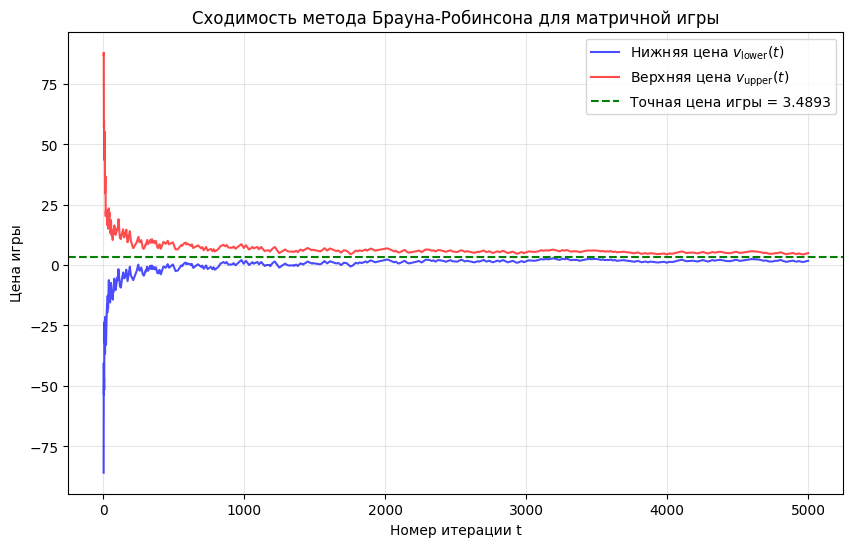

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, T+1), lower_vals, label='Нижняя цена $v_{\\text{lower}}(t)$', color='blue', alpha=0.7)
plt.plot(range(1, T+1), upper_vals, label='Верхняя цена $v_{\\text{upper}}(t)$', color='red', alpha=0.7)
if v_exact is not None:
    plt.axhline(y=v_exact, color='green', linestyle='--', linewidth=1.5, label=f'Точная цена игры = {v_exact:.4f}')
plt.xlabel('Номер итерации t')
plt.ylabel('Цена игры')
plt.title('Сходимость метода Брауна-Робинсона для матричной игры')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()